In [1]:
# Loading Dataset

In [2]:
import pandas as pd
df = pd.read_csv("/content/SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [8]:
# Checking duplicates
df.duplicated().sum()

np.int64(17)

In [9]:
# Ensuring correct data types
# Numeric Columns

numeric_columns = [
    'Postal Code',
    'Sales',
    'Quantity',
    'Discount',
    'Profit'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Categorical Columns

categorical_columns = [
    'Ship Mode',
    'Segment',
    'Country',
    'City',
    'State',
    'Region',
    'Category',
    'Sub-Category'
]

for col in categorical_columns:
  df[col] = df[col].astype("category")

In [10]:
# Checking Duplicates
df.dtypes

,0
Ship Mode,category
Segment,category
Country,category
City,category
State,category
Postal Code,int64
Region,category
Category,category
Sub-Category,category
Sales,float64


In [11]:
# Removing Duplicates

df = df.drop_duplicates()

after = len(df)

print(after)

9977


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Saving the Cleaned Dataset

df.to_csv("/content/SampleSuperstore_Cleaned.csv", index=False)

In [14]:
# Implementing Risk Score

import numpy as np

# 1.Profit Margin

df["Profit Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], 0)

# 2.Individual Risk Components

# Discount Risk
# 10% discount = no risk
# 50%+ discount = maximum risk

df["Discount Risk"] = np.clip(
    (df["Discount"] - 0.10) / 0.40,0,1)

# Profit Margin Risk
# 20%+ margin = no risk
# -10% or lower = maximum risk

df["Margin Risk"] = np.clip(
    (0.20 - df["Profit Margin"]) / 0.30,0,1)

# Quantity Risk
# 1 unit = no risk
# 10+ units = maximum risk

df["Quantity Risk"] = np.clip(
    (df["Quantity"] - 1) / 9,0,1)

# 3.Calculate final Risk Score

df["Risk Score"] = (
    100 * (
        0.40 * df["Margin Risk"] +
        0.40 * df["Discount Risk"] +
        0.20 * df["Quantity Risk"]))

# Round the score
df["Risk Score"] = df["Risk Score"].round(2)

# 4.Optional risk classification

df["Risk Level"] = pd.cut(
    df["Risk Score"],
    bins=[-1, 30, 60, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"])



In [15]:
df.head(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin,Discount Risk,Margin Risk,Quantity Risk,Risk Score,Risk Level
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0.1600,0.000,0.133333,0.111111,7.56,Low Risk
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,0.3000,0.000,0.000000,0.222222,4.44,Low Risk
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0.4700,0.000,0.000000,0.111111,2.22,Low Risk
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-0.4000,0.875,1.000000,0.444444,83.89,High Risk
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0.1125,0.250,0.291667,0.111111,23.89,Low Risk
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.8600,7,0.00,14.1694,0.2900,0.000,0.000000,0.666667,13.33,Low Risk
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.2800,4,0.00,1.9656,0.2700,0.000,0.000000,0.333333,6.67,Low Risk
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152,0.1000,0.250,0.333333,0.555556,34.44,Medium Risk
8,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.5040,3,0.20,5.7825,0.3125,0.250,0.000000,0.222222,14.44,Low Risk
9,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.9000,5,0.00,34.4700,0.3000,0.000,0.000000,0.444444,8.89,Low Risk


In [16]:
# Convert Risk Score into the target

df["Risk Target"] = np.where(
    df["Risk Score"] > 60,
    1,
    0
)

df["Risk Label"] = df["Risk Target"].map({
    0: "Not High Risk",
    1: "High Risk"
})

print(df["Risk Label"].value_counts())

Risk Label
Not High Risk    8640
High Risk        1337
Name: count, dtype: int64


In [17]:
# Select features

features = [
    "Discount",
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode",
    "Quantity",
    "Sales"
]

X = df[features]
y = df["Risk Target"]

In [18]:
# Train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (7981, 8)
Testing size: (1996, 8)


In [19]:
# Handle categorical variables

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

numeric_features = [
    "Discount",
    "Quantity",
    "Sales"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [20]:
# Train Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [21]:
# Predictions

y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [22]:
# Evaluate accuracy, precision and recall

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not High Risk", "High Risk"]
    )
)

Accuracy : 0.9815
Precision: 0.9563
Recall   : 0.9026

Classification Report:
               precision    recall  f1-score   support

Not High Risk       0.99      0.99      0.99      1729
    High Risk       0.96      0.90      0.93       267

     accuracy                           0.98      1996
    macro avg       0.97      0.95      0.96      1996
 weighted avg       0.98      0.98      0.98      1996



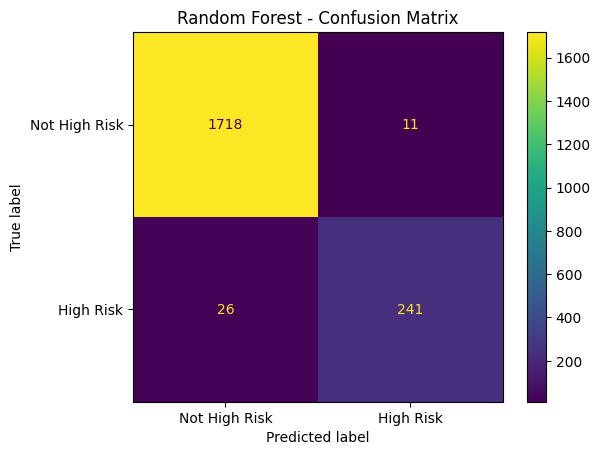

In [23]:
# Confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not High Risk", "High Risk"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [24]:
# Feature importance

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                                  Feature  Importance
31                      numeric__Discount    0.598213
6       categorical__Sub-Category_Binders    0.067264
33                         numeric__Sales    0.062650
32                      numeric__Quantity    0.037632
23               categorical__Region_West    0.028583
15        categorical__Sub-Category_Paper    0.026616
20            categorical__Region_Central    0.023141
19       categorical__Sub-Category_Tables    0.019732
0         categorical__Category_Furniture    0.013328
1   categorical__Category_Office Supplies    0.012056
5           categorical__Sub-Category_Art    0.011559
21               categorical__Region_East    0.009797
17      categorical__Sub-Category_Storage    0.009215
3   categorical__Sub-Category_Accessories    0.008799
2        categorical__Category_Technology    0.006421


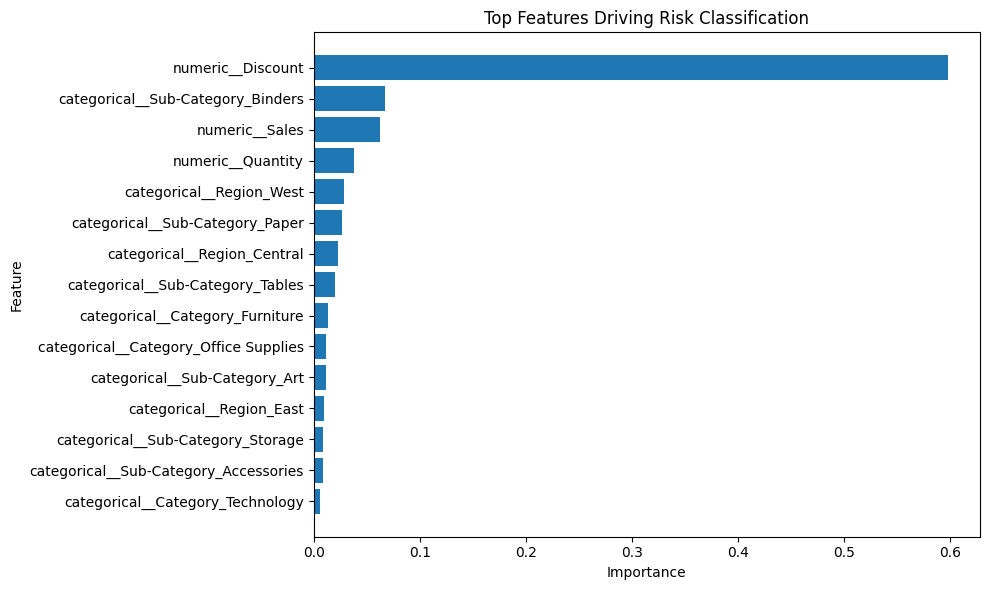

In [25]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Driving Risk Classification")

plt.tight_layout()
plt.show()

In [26]:
# Risk score distribution by category / sub-category

category_risk = (
    df.groupby("Category", observed=True)
      .agg(
          transactions=("Risk Score", "count"),
          avg_risk_score=("Risk Score", "mean"),
          median_risk_score=("Risk Score", "median"),
          high_risk_count=("Risk Score", lambda x: (x > 60).sum()),
          high_risk_pct=("Risk Score", lambda x: (x > 60).mean() * 100)
      )
      .round(2)
      .sort_values("avg_risk_score", ascending=False)
)

category_risk_summary = category_risk.reset_index().to_dict("records")

# Risk distribution by Sub-Category

subcategory_risk = (
    df.groupby("Sub-Category", observed=True)
      .agg(
          transactions=("Risk Score", "count"),
          avg_risk_score=("Risk Score", "mean"),
          median_risk_score=("Risk Score", "median"),
          high_risk_count=("Risk Score", lambda x: (x > 60).sum()),
          high_risk_pct=("Risk Score", lambda x: (x > 60).mean() * 100)
      )
      .round(2)
      .sort_values("avg_risk_score", ascending=False)
)

subcategory_risk_summary = subcategory_risk.reset_index().to_dict("records")

In [27]:
# Profit leakage totals by region and segment

# Negative-profit transactions represent profit leakage
df["Profit Leakage"] = np.where(
    df["Profit"] < 0,
    -df["Profit"],
    0
)

df["Leakage Transaction"] = (df["Profit"] < 0).astype(int)

In [28]:
region_leakage = (
    df.groupby("Region", observed=True)
      .agg(
          transactions=("Profit", "count"),
          total_sales=("Sales", "sum"),
          total_profit=("Profit", "sum"),
          profit_leakage=("Profit Leakage", "sum"),
          leakage_transactions=("Leakage Transaction", "sum"),
          avg_risk_score=("Risk Score", "mean")
      )
      .round(2)
      .sort_values("profit_leakage", ascending=False)
)

region_leakage_summary = region_leakage.reset_index().to_dict("records")

In [29]:
segment_leakage = (
    df.groupby("Segment", observed=True)
      .agg(
          transactions=("Profit", "count"),
          total_sales=("Sales", "sum"),
          total_profit=("Profit", "sum"),
          profit_leakage=("Profit Leakage", "sum"),
          leakage_transactions=("Leakage Transaction", "sum"),
          avg_risk_score=("Risk Score", "mean")
      )
      .round(2)
      .sort_values("profit_leakage", ascending=False)
)

segment_leakage_summary = segment_leakage.reset_index().to_dict("records")

In [30]:
# Discount vs Profit Margin correlation summary

discount_margin_corr = df["Discount"].corr(
    df["Profit Margin"]
)

In [31]:
df["Discount Band"] = pd.cut(
    df["Discount"],
    bins=[-0.001, 0.10, 0.20, 0.30, 0.40, 0.50, 1.00],
    labels=[
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50%+"
    ]
)

discount_margin_summary = (
    df.groupby("Discount Band", observed=True)
      .agg(
          transactions=("Profit Margin", "count"),
          avg_discount=("Discount", "mean"),
          avg_profit_margin=("Profit Margin", "mean"),
          avg_profit=("Profit", "mean"),
          avg_risk_score=("Risk Score", "mean")
      )
      .round(4)
      .reset_index()
)

discount_margin_summary["avg_discount"] = (
    discount_margin_summary["avg_discount"] * 100
).round(2)

discount_margin_summary["avg_profit_margin"] = (
    discount_margin_summary["avg_profit_margin"] * 100
).round(2)

discount_margin_corr_summary = {
    "overall_correlation_discount_vs_profit_margin": round(
        discount_margin_corr, 4
    ),
    "interpretation": (
        "Negative = higher discount tends to be associated "
        "with lower profit margin; positive = higher discount "
        "tends to be associated with higher profit margin."
    ),
    "discount_bands": discount_margin_summary.to_dict("records")
}

In [32]:
# Top 5 highest-risk categories

top_5_risk_categories = (
    df.groupby("Category", observed=True)
      .agg(
          transactions=("Risk Score", "count"),
          avg_risk_score=("Risk Score", "mean"),
          high_risk_pct=("Risk Score", lambda x: (x > 60).mean() * 100),
          avg_discount=("Discount", "mean"),
          avg_profit_margin=("Profit Margin", "mean"),
          total_sales=("Sales", "sum"),
          total_profit=("Profit", "sum"),
          profit_leakage=("Profit Leakage", "sum")
      )
      .sort_values("avg_risk_score", ascending=False)
      .head(5)
      .round(2)
      .reset_index()
)

# Convert decimal values into percentages for readability
top_5_risk_categories["avg_discount"] = (
    top_5_risk_categories["avg_discount"] * 100
).round(2)

top_5_risk_categories["avg_profit_margin"] = (
    top_5_risk_categories["avg_profit_margin"] * 100
).round(2)

top_5_risk_categories_summary = (
    top_5_risk_categories.to_dict("records")
)

In [33]:
# Predictive model summary

# Model Performane

from sklearn.metrics import accuracy_score, precision_score, recall_score

model_metrics = {
    "accuracy": round(accuracy_score(y_test, y_pred), 4),
    "precision": round(precision_score(y_test, y_pred), 4),
    "recall": round(recall_score(y_test, y_pred), 4)
}

# Top model features

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = model.named_steps[
    "classifier"
].feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

top_features_summary = feature_importance.round(4).to_dict("records")

# Overall prediction distribution

prediction_counts = pd.Series(y_pred).value_counts()

prediction_distribution = {
    "Not High Risk": int(prediction_counts.get(0, 0)),
    "High Risk": int(prediction_counts.get(1, 0)),
    "total_predictions": int(len(y_pred))
}

prediction_distribution["high_risk_pct"] = round(
    prediction_distribution["High Risk"]
    / prediction_distribution["total_predictions"]
    * 100,
    2
)

In [34]:
# Final LLM-ready summary object

llm_summary = {
    "risk_distribution": {
        "by_category": category_risk_summary,
        "by_subcategory": subcategory_risk_summary
    },

    "profit_leakage": {
        "by_region": region_leakage_summary,
        "by_segment": segment_leakage_summary
    },

    "discount_profit_relationship": discount_margin_corr_summary,

    "top_5_highest_risk_categories": top_5_risk_categories_summary,

    "predictive_model": {
        "metrics": model_metrics,
        "top_features": top_features_summary,
        "test_prediction_distribution": prediction_distribution
    }
}

In [35]:
# AI-Generated Profit Optimization

!pip install groq
import os
import json
from groq import Groq


SYSTEM_PROMPT = """
You are a senior retail pricing and profitability analyst.

Your task is to convert the provided transaction-level summary statistics
and predictive-model findings into specific, evidence-based profit
optimization actions.

Rules:
1. Use ONLY the numerical results and findings supplied by the user.
2. Do not invent facts, thresholds, causes, percentages, or business conditions.
3. Do not use outside knowledge or generic retail advice.
4. Distinguish observed patterns from model-derived signals.
5. Do not claim causation when the data only shows correlation or association.
6. Do not assume higher discounts reduce sales unless the supplied data
   demonstrates that relationship.
7. Recommend an exact discount cap only when the supplied evidence supports
   that threshold. Otherwise recommend a test or monitoring range.
8. Prioritize actions using profit leakage, transaction volume, risk
   concentration, margins, and discount exposure.
9. Do not describe Risk Score as an observed profit-loss measurement.
10. Do not describe model predictions as guaranteed future losses.
11. Mention when evidence is insufficient or conflicting.

Output:
1. Executive Recommendation
2. Ranked Actions
3. Evidence and Rationale
4. Data Limitations

Maximum 5 ranked actions.
Use a concise business-report tone.
"""


def generate_profit_optimization_recommendations(
    llm_summary: dict,
    model_name: str = "llama-3.3-70b-versatile"
) -> str:
    """
    Send aggregated retail profitability findings to Groq and
    generate evidence-grounded profit optimization recommendations.
    """

    api_key = os.getenv("Your_Groq_API_KEY")

    if not api_key:
        raise EnvironmentError(
            "GROQ_API_KEY is not set. "
            "Set it as an environment variable before calling this function."
        )

    client = Groq(api_key=api_key)

    # Convert Python dictionary to compact JSON
    evidence_json = json.dumps(
        llm_summary,
        indent=2,
        default=str
    )

    user_prompt = f"""
Analyze the following retail profitability evidence and produce a ranked
set of actionable profit optimization recommendations.

Objective:
Identify the highest-priority opportunities to reduce profit leakage,
improve pricing discipline, reduce unnecessary discount exposure, and
focus management attention where the financial impact is greatest.

Evidence:

{evidence_json}

Requirements:

1. Produce no more than 5 ranked actions.
2. For each action provide:
   - Priority
   - Action
   - Target
   - Why
   - Evidence
   - Expected objective
3. Use only evidence contained in the supplied data.
4. Do not invent an exact discount cap unless the data supports it.
5. Where evidence is insufficient for an exact threshold, recommend a
   controlled test or monitoring range instead.
6. Do not claim that discount causes lower sales or profit unless the
   supplied evidence establishes causality.
7. Prioritize financial impact, not just average risk score.
8. Clearly distinguish engineered Risk Score signals from observed
   financial outcomes.
9. Treat predictive-model output as a risk-classification signal, not
   proof of future profit loss.
10. End with a Data Limitations section.
"""

    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    "role": "system",
                    "content": SYSTEM_PROMPT
                },
                {
                    "role": "user",
                    "content": user_prompt
                }
            ],
            temperature=0.2,
            max_completion_tokens=2500
        )

        return response.choices[0].message.content

    except Exception as e:
        raise RuntimeError(
            f"Groq API request failed: {e}"
        ) from e

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 1.2 MB/s eta 0:00:00


In [36]:
# LLM SUMMARY

import json

with open("/content/llm_summary.json", "w") as f:
    json.dump(
        llm_summary,
        f,
        indent=2,
        default=str
    )

print("Created successfully.")

Created successfully.


In [37]:
import os

print(os.path.exists("/content/llm_summary.json"))

True


In [38]:
df = df.round(2)
df.to_csv("/content/SampleSuperstore_risk_scored.csv", index=False)

In [39]:
category_leakage = (
    df.groupby("Category", observed=True)
      .agg(
          transactions=("Profit", "count"),
          total_sales=("Sales", "sum"),
          total_profit=("Profit", "sum"),
          profit_leakage=("Profit Leakage", "sum"),
          avg_risk_score=("Risk Score", "mean")
      )
      .round(2)
      .sort_values("profit_leakage", ascending=False)
      .reset_index()
)

print(category_leakage)

          Category  transactions  total_sales  total_profit  profit_leakage  \
0        Furniture          2118    741306.25      18421.64        60924.24   
1  Office Supplies          6012    718735.12     122363.87        56609.11   
2       Technology          1847    836154.02     145455.44        38579.99   

   avg_risk_score  
0           33.26  
1           22.38  
2           24.10  


In [40]:
print(category_leakage)

          Category  transactions  total_sales  total_profit  profit_leakage  \
0        Furniture          2118    741306.25      18421.64        60924.24   
1  Office Supplies          6012    718735.12     122363.87        56609.11   
2       Technology          1847    836154.02     145455.44        38579.99   

   avg_risk_score  
0           33.26  
1           22.38  
2           24.10  


In [42]:
category_leakage_summary = category_leakage.reset_index().to_dict("records")
llm_summary["profit_leakage"]["by_category"] = category_leakage_summary

In [44]:
import json

with open("/content/llm_summary.json", "w") as f:
    json.dump(
        llm_summary,
        f,
        indent=2,
        default=str
    )

print("llm_summary.json updated successfully.")

llm_summary.json updated successfully.


In [45]:
from google.colab import files

files.download("/content/llm_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>